# BA model


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LinearRegression

def ba_model(n,l):
    G=nx.barabasi_albert_graph(n,l)
    return G

def plot_degree_dist(G):
    degree_sequence=[d for n,d in G.degree()]
    degree_counts= np.bincount(degree_sequence)   
    degrees = np.nonzero(degree_counts)[0]   # degree list, on x axis
    probabilities = degree_counts[degrees]/ sum(degree_counts)  #y axis

    plt.figure(figsize=(8,6))
    plt.scatter(degrees,probabilities)
    plt.xlabel('Degree')
    plt.ylabel('Degree probabilities')
    plt.title(f'Degree Distribution of BA {G}')
    plt.show()


def plot_log_degree_dist(G):
    degree_sequence=[d for n,d in G.degree()]
    degree_counts= np.bincount(degree_sequence)   
    degrees = np.nonzero(degree_counts)[0]   # degree list, on x axis
    probabilities = degree_counts[degrees] / sum(degree_counts)  #y axis
    
    log_degree=np.log(degrees)
    log_probabilities=np.log(probabilities)

    plt.figure(figsize=(8,6))
    plt.scatter(log_degree,log_probabilities)
    plt.xlabel('log-Degree')
    plt.ylabel('log-Degree probabilities')
    plt.title(f'log-log Degree Distribution of BA {G}')


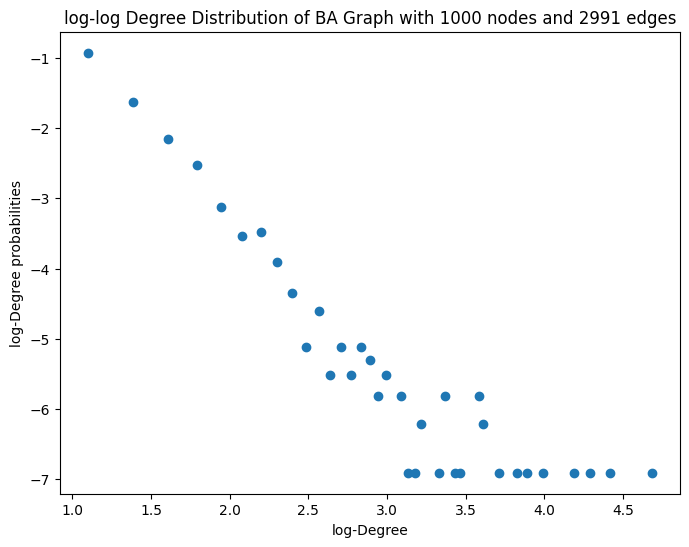

In [21]:
model1=ba_model(1000,3)
plot_log_degree_dist(model1)


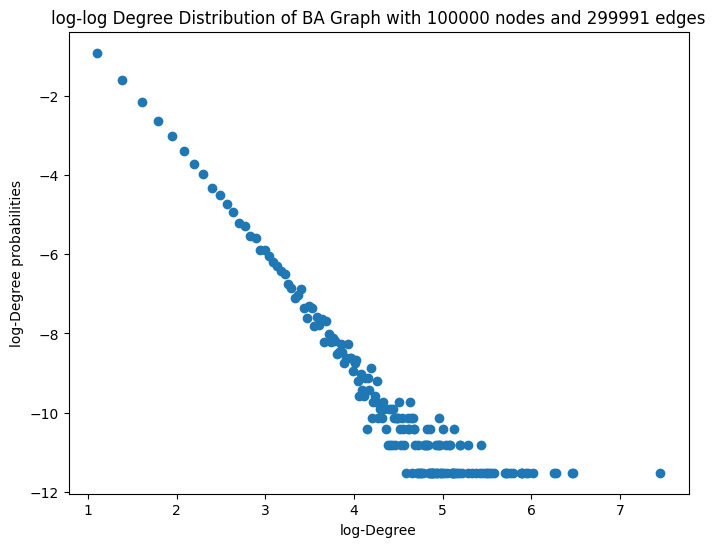

In [22]:
model11=ba_model(100000,3)
plot_log_degree_dist(model11)


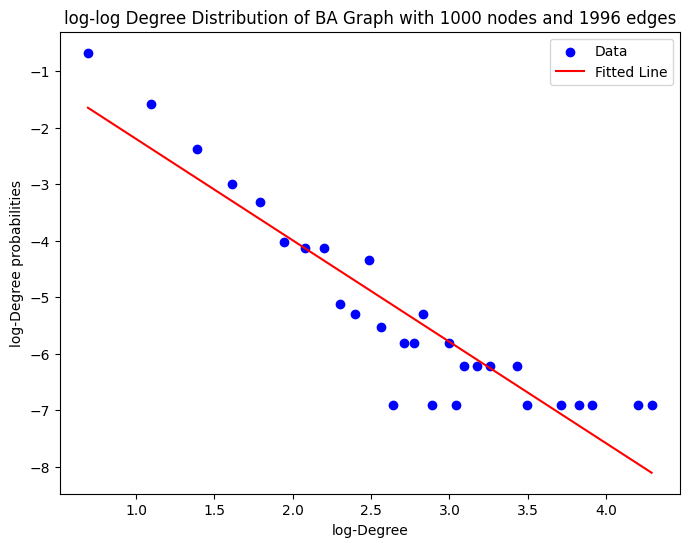

[-1.79543154] -0.40463255903536854


In [3]:
model2=ba_model(1000,2)

ba_linear(model2)

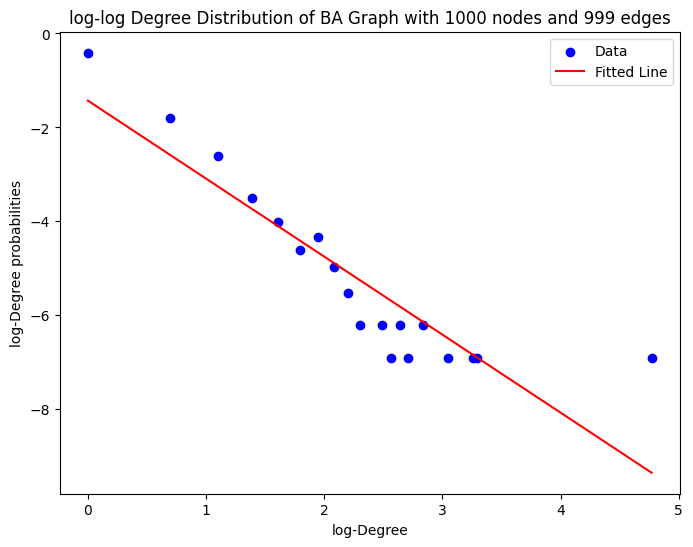

[-1.65957844] -1.4312858024493793


In [4]:
model3=ba_model(1000,1)

ba_linear(model3)

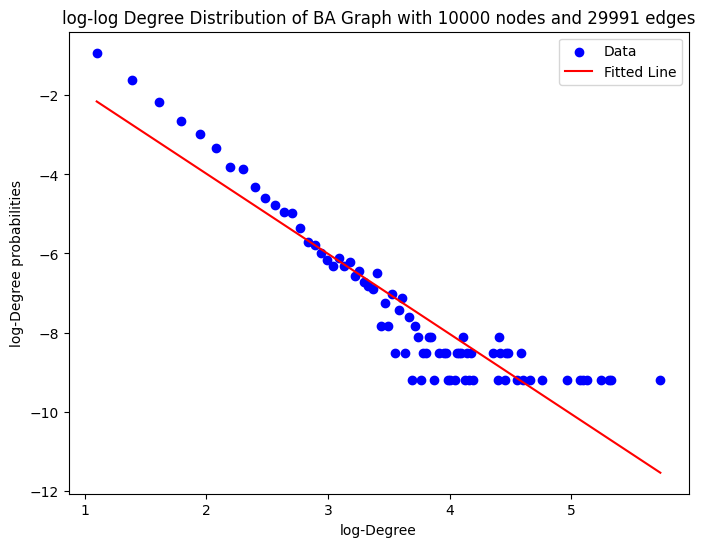

[-2.02663138] 0.07291252843003626


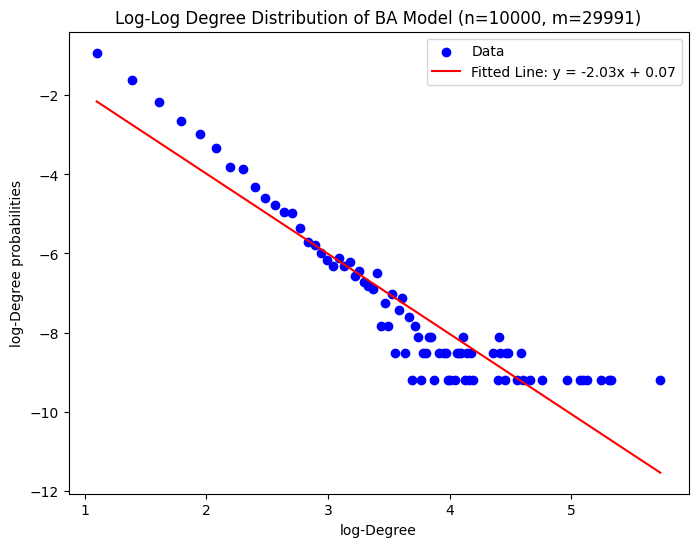

Estimated Power-Law Exponent (γ): -2.03
Intercept: 0.07
R-squared: 0.8575


In [6]:
model4=ba_model(10000,3)

ba_linear(model4)
ba_power_law(model4)

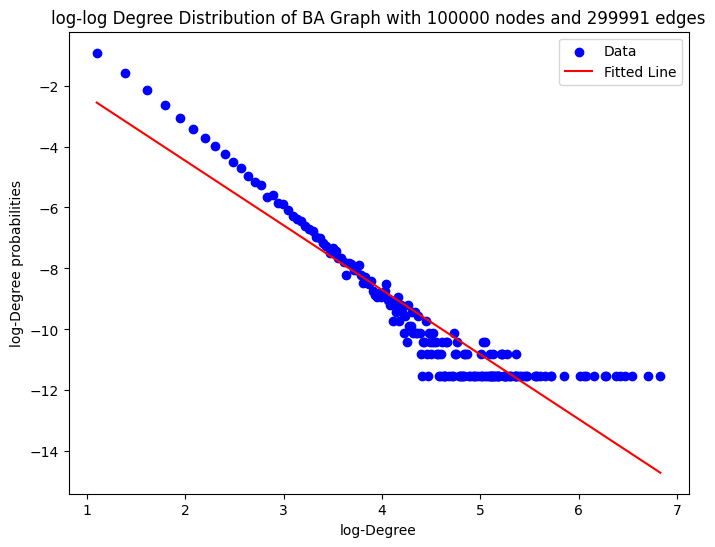

[-2.11938638] -0.22974404164720674


In [6]:
model5=ba_model(100000,3)

ba_linear(model5)

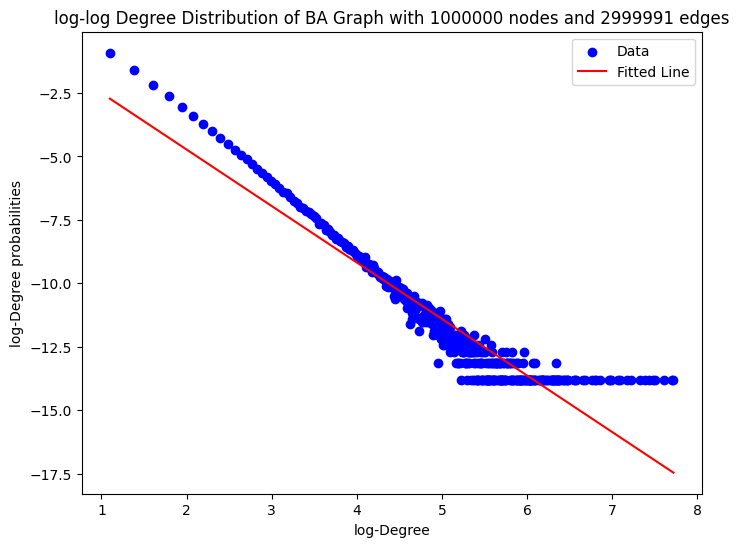

[-2.22525612] -0.27874167040286046


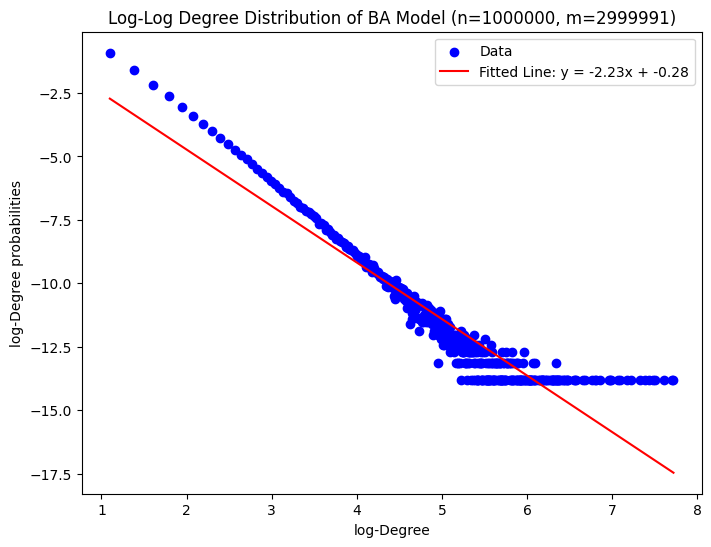

Estimated Power-Law Exponent (γ): -2.23
Intercept: -0.28
R-squared: 0.8795


In [7]:
model6=ba_model(1000000,3)

ba_linear(model6)
ba_power_law(model6)

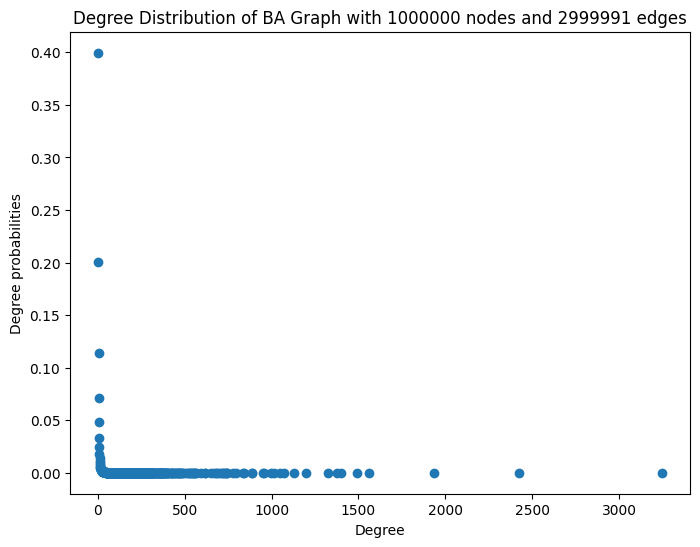

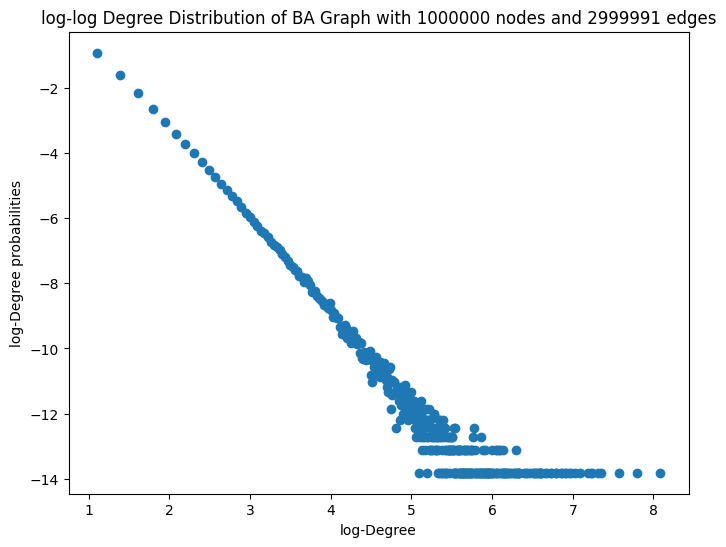

In [ ]:
plot_degree_dist(model6)
plot_log_degree_dist(model6)

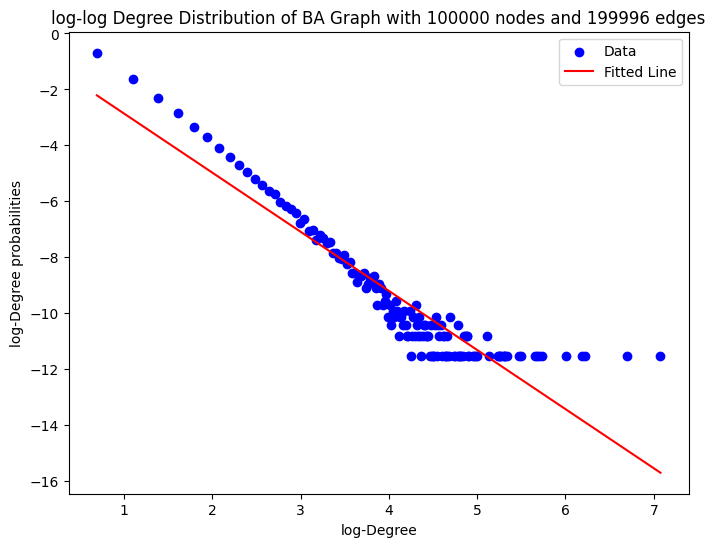

[-2.11311095] -0.7472102309334332


In [ ]:
model7=ba_model(100000,2)

ba_linear(model7)

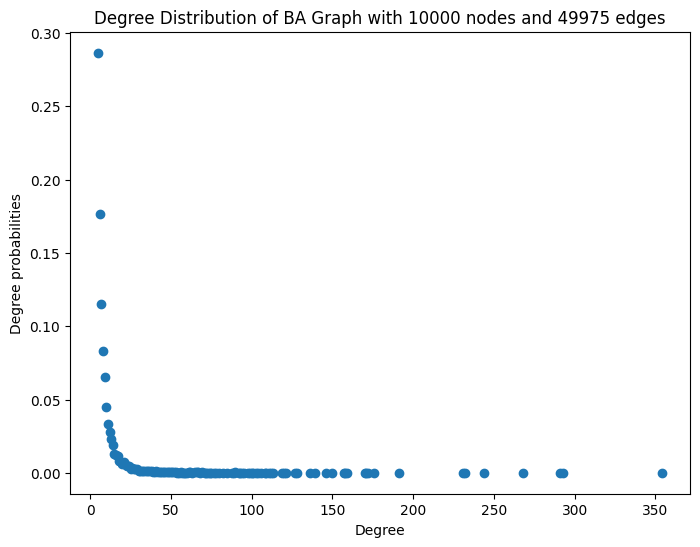

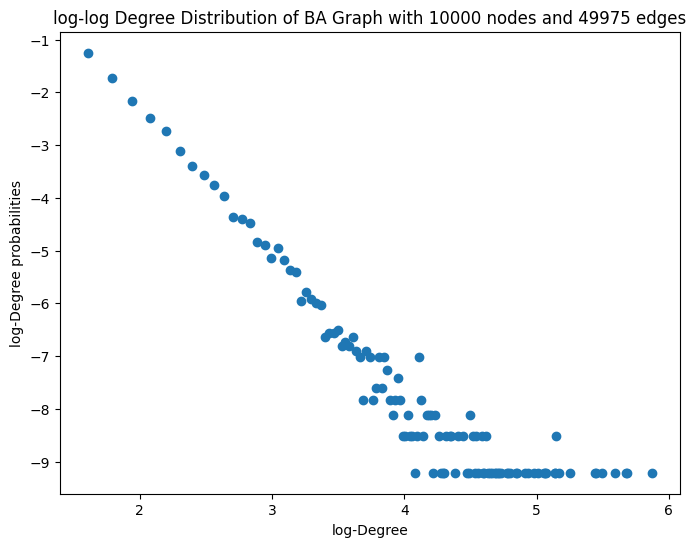

In [8]:
model8=ba_model(10000,5)

plot_degree_dist(model8)
plot_log_degree_dist(model8)

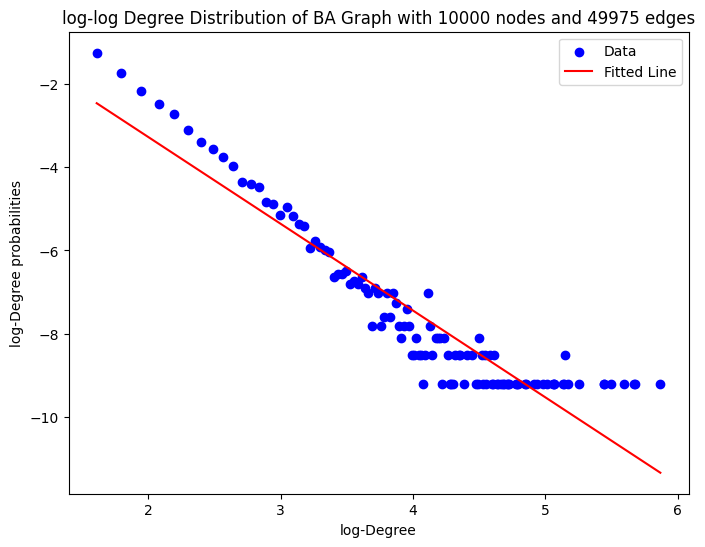

[-2.0845724] 0.8918672585422867


In [9]:
ba_linear(model8)

In [ ]:

degree_sequence=[1,1,1,3,3,4,4,5,6]
degree= np.bincount(degree_sequence)
print(degree)

degrees=np.nonzero(degree)
print(degrees)

[0 3 0 2 2 1 1]
(array([1, 3, 4, 5, 6], dtype=int64),)


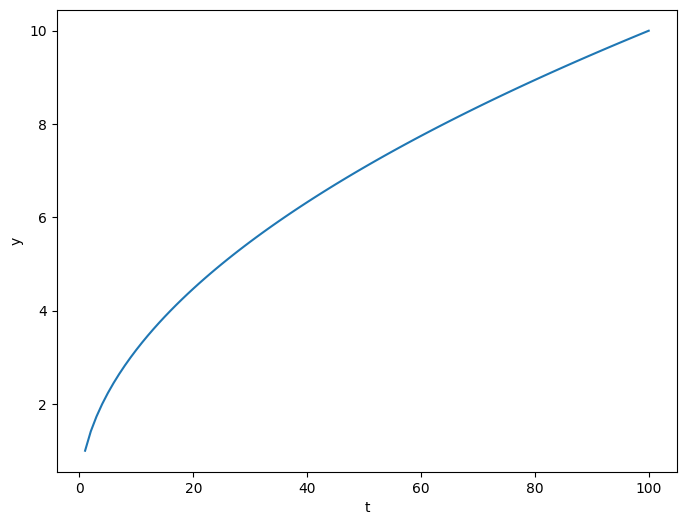

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t=np.linspace(1,100,100)
y=np.sqrt(t)

plt.figure(figsize=(8,6))
plt.plot(t,y)
plt.xlabel('t')
plt.ylabel('y')
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import random

def simulate_ba_model(N, m):
    nodes = list(range(m))
    edges = [(i, j) for i in nodes for j in nodes if i < j]
    degree = {i: m-1 for i in nodes}

    for new_node in range(m, N):
        targets = []
        degrees = list(degree.values())
        nodes_list = list(degree.keys())
        
        for _ in range(m):
            chosen = random.choices(nodes_list, weights=degrees, k=1)[0]
            while chosen in targets:
                chosen = random.choices(nodes_list, weights=degrees, k=1)[0]
            targets.append(chosen)

        for target in targets:
            edges.append((new_node, target))
            degree[target] += 1

        degree[new_node] = m

    return degree

def estimate_power_law_exponent_MLE(degrees, k_min):
    """ Use Maximum Likelihood Estimation (MLE) to estimate the power-law exponent. """
    degrees = np.array(degrees)
    degrees = degrees[degrees >= k_min]  # Only degrees >= k_min
    n = len(degrees)
    if n == 0:
        raise ValueError("No data above k_min.")
    
    # MLE formula for power-law (continuous approximation)
    gamma_hat = 1 + n / np.sum(np.log(degrees / (k_min - 0.5)))
    
    return gamma_hat

# ======= Main Execution =======
N = 100000
m = 3
degree = simulate_ba_model(N, m)
degree_values = list(degree.values())

k_min = 5  # You can tune this
gamma_hat = estimate_power_law_exponent_MLE(degree_values, k_min)

print(f"Estimated power-law exponent (gamma) using MLE = {gamma_hat:.3f}")

# Optional: Plot degree distribution
hist, bins = np.histogram(degree_values, bins=range(1, max(degree_values)+2))
plt.figure(figsize=(8,6))
plt.loglog(bins[:-1], hist, 'o')
plt.xlabel('Degree k')
plt.ylabel('Frequency')
plt.title('BA Model Degree Distribution (log-log)')
plt.grid(True)
plt.show()


KeyboardInterrupt: 

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import linregress

def ba_model(N, m):
    """Simulate a BA model graph with N nodes and m edges per new node."""
    G = nx.barabasi_albert_graph(N, m)
    return G

def plot_log_log(G):
    """Plot the degree distribution of G on log-log scale."""
    degree_sequence = [d for n, d in G.degree()]
    degree_counts = np.bincount(degree_sequence)
    degrees = np.nonzero(degree_counts)[0]
    probabilities = degree_counts[degrees] / sum(degree_counts)

    log_degrees = np.log(degrees)
    log_probabilities = np.log(probabilities)

    plt.figure(figsize=(8,6))
    plt.scatter(log_degrees, log_probabilities)
    plt.xlabel('log Degree')
    plt.ylabel('log Probability')
    plt.title('Log-Log Degree Distribution of BA Model')
    plt.show()

def estimate_power_law_exponent_MLE(degrees, k_min):
    """
    Estimate power-law exponent (gamma) using MLE,
    and calculate maximum degree, average degree, and R^2 for log-log fit.
    """
    degrees = np.array(degrees)
    degrees_all = degrees.copy()

    # Step 1: Statistics
    max_degree = np.max(degrees_all)
    average_degree = np.mean(degrees_all)

    # Step 2: Filter degrees >= k_min for MLE
    degrees = degrees[degrees >= k_min]
    n = len(degrees)
    if n == 0:
        raise ValueError("No data points above k_min.")

    # Step 3: MLE estimation
    gamma_hat = 1 + n / np.sum(np.log(degrees / (k_min - 0.5)))

    # Step 4: Estimate R^2 by linear regression on log-log
    degree_counts = np.bincount(degrees_all)
    bins = np.nonzero(degree_counts)[0]
    probabilities = degree_counts[bins] / sum(degree_counts)

    # Only use points where degree >= k_min and probability > 0
    mask = (bins >= k_min) & (probabilities > 0)
    log_x = np.log10(bins[mask])
    log_y = np.log10(probabilities[mask])

    if len(log_x) < 2:
        raise ValueError("Not enough data points for regression.")

    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    r_squared = r_value ** 2

    return gamma_hat, max_degree, average_degree, r_squared




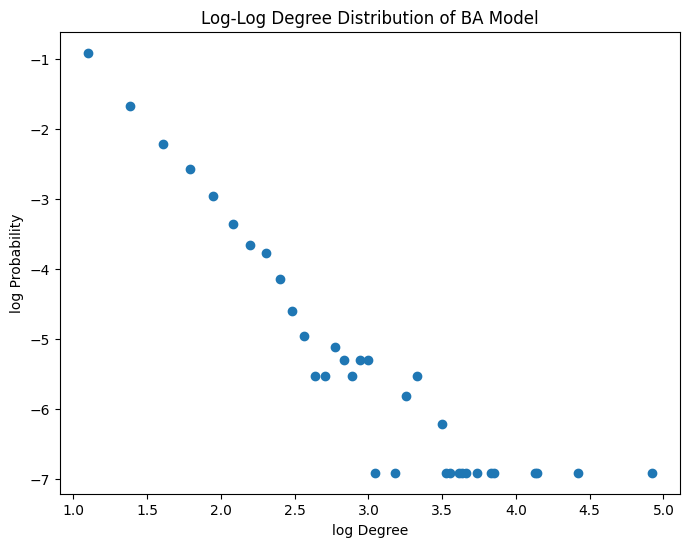

MLE estimated gamma = 2.730
Maximum degree = 137
Average degree = 5.982
R-squared of log-log fit = 0.8130


In [42]:
if __name__ == "__main__":
    N = 1000
    m = 3

    # 1. Simulate BA network
    G = ba_model(N, m)

    # 2. Plot degree distribution
    plot_log_log(G)

    # 3. Estimate statistics
    degrees = [d for n, d in G.degree()]
    k_min = 5
    gamma_hat, max_degree, average_degree, r_squared = estimate_power_law_exponent_MLE(degrees, k_min)

    print(f"MLE estimated gamma = {gamma_hat:.3f}")
    print(f"Maximum degree = {max_degree}")
    print(f"Average degree = {average_degree:.3f}")
    print(f"R-squared of log-log fit = {r_squared:.4f}")

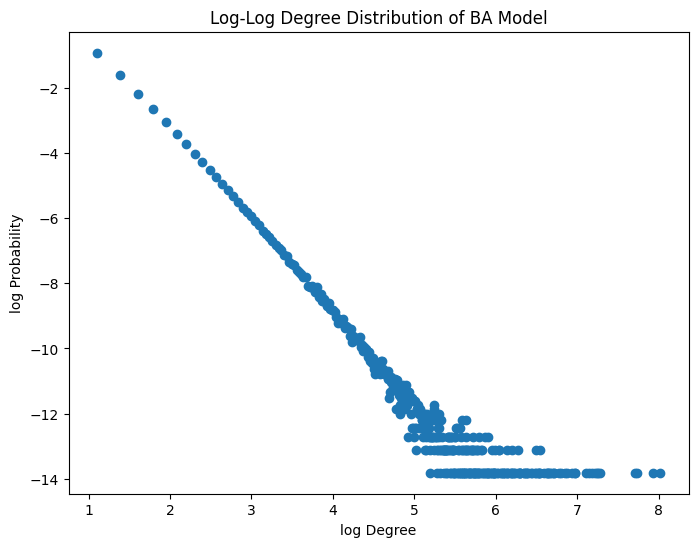

MLE estimated gamma = 2.742
Maximum degree = 3049
Average degree = 6.000
R-squared of log-log fit = 0.8609


In [44]:
if __name__ == "__main__":
    N = 1000000
    m = 3

    # 1. Simulate BA network
    G = ba_model(N, m)

    # 2. Plot degree distribution
    plot_log_log(G)

    # 3. Estimate statistics
    degrees = [d for n, d in G.degree()]
    k_min = 5
    gamma_hat, max_degree, average_degree, r_squared = estimate_power_law_exponent_MLE(degrees, k_min)

    print(f"MLE estimated gamma = {gamma_hat:.3f}")
    print(f"Maximum degree = {max_degree}")
    print(f"Average degree = {average_degree:.3f}")
    print(f"R-squared of log-log fit = {r_squared:.4f}")